In [17]:
import os
import requests
import pandas as pd

In [18]:
jdx_folder = "Data/jdx"
mol_folder = "Data/mol"

os.makedirs(jdx_folder, exist_ok=True)
os.makedirs(mol_folder, exist_ok=True)

print("Folders ready")

Folders ready


In [ ]:
BASE_URL = "https://webbook.nist.gov/cgi/cbook.cgi"

def download_ir(nist_id):

    params = {
        "JCAMP": nist_id,
        "Type": "IR",
        "Index": 0
    }

    r = requests.get(BASE_URL, params=params)

    if "Spectrum not found" in r.text:
        print("No IR spectrum for", nist_id)
        return

    filename = f"{jdx_folder}/{nist_id}-IR.jdx"

    with open(filename, "w") as f:
        f.write(r.text)

    print("Saved", filename)

In [21]:
def download_structure(nist_id):

    params = {"Str2File": nist_id}

    r = requests.get(BASE_URL, params=params)

    filename = f"{mol_folder}/{nist_id}.mol"

    with open(filename, "w") as f:
        f.write(r.text)

    print("Saved", filename)

In [5]:
molecules = [
    "C100016",
    "C100027",
    "C100094",
    "C100107"
]

for m in molecules:
    download_ir(m)
    download_structure(m)

Saved Data/jdx/C100016-IR.jdx
Saved Data/mol/C100016.mol
Saved Data/jdx/C100027-IR.jdx
Saved Data/mol/C100027.mol
No IR spectrum for C100094
Saved Data/mol/C100094.mol
Saved Data/jdx/C100107-IR.jdx
Saved Data/mol/C100107.mol


In [22]:
import os
import re
import requests
from bs4 import BeautifulSoup

In [23]:
jdx_folder = "Data/jdx"
mol_folder = "Data/mol"

os.makedirs(jdx_folder, exist_ok=True)
os.makedirs(mol_folder, exist_ok=True)

print("Folders ready")

Folders ready


In [24]:
NIST_URL = "https://webbook.nist.gov/cgi/cbook.cgi"

ID_RE = re.compile(r'/cgi/cbook.cgi\?ID=(.*?)&')

In [25]:
def search_nist_formula(formula):

    params = {
        "Formula": formula,
        "Units": "SI",
        "AllowOther": "on",
        "NoIon": "on",
        "cIR": "on"
    }

    r = requests.get(NIST_URL, params=params)

    soup = BeautifulSoup(r.text, "html.parser")

    ids = []

    for link in soup.find_all("a", href=True):
        match = ID_RE.search(link["href"])
        if match:
            ids.append(match.group(1))

    return ids

In [26]:
def download_ir(nist_id):

    params = {
        "JCAMP": nist_id,
        "Type": "IR",
        "Index": 0
    }

    r = requests.get(NIST_URL, params=params)

    if "Spectrum not found" in r.text:
        print("No IR spectrum:", nist_id)
        return False

    filename = f"{jdx_folder}/{nist_id}-IR.jdx"

    with open(filename, "w") as f:
        f.write(r.text)

    print("Saved IR:", nist_id)

    return True

In [27]:
def download_mol(nist_id):

    params = {"Str2File": nist_id}

    r = requests.get(NIST_URL, params=params)

    filename = f"{mol_folder}/{nist_id}.mol"

    with open(filename, "w") as f:
        f.write(r.text)

    print("Saved MOL:", nist_id)

In [28]:
all_ids = []

for i in range(1,10):

    formula = f"C{i}"

    ids = search_nist_formula(formula)

    print(f"{formula} → {len(ids)} molecules found")

    all_ids.extend(ids)

C1 → 107 molecules found
C2 → 276 molecules found
C3 → 369 molecules found
C4 → 400 molecules found
C5 → 400 molecules found
C6 → 400 molecules found
C7 → 400 molecules found
C8 → 400 molecules found
C9 → 400 molecules found


In [29]:
for nist_id in all_ids:

    success = download_ir(nist_id)

    if success:
        download_mol(nist_id)

Saved IR: B6000567
Saved MOL: B6000567
Saved IR: B6000506
Saved MOL: B6000506
Saved IR: B6001436
Saved MOL: B6001436
Saved IR: C353559
Saved MOL: C353559
Saved IR: C353548
Saved MOL: C353548
Saved IR: C558134
Saved MOL: C558134
Saved IR: C75627
Saved MOL: C75627
Saved IR: C75638
Saved MOL: C75638
Saved IR: C471341
Saved MOL: C471341
Saved IR: B6004659
Saved MOL: B6004659
Saved IR: B6000507
Saved MOL: B6000507
Saved IR: C75718
Saved MOL: C75718
Saved IR: C75445
Saved MOL: C75445
Saved IR: C2757235
Saved MOL: C2757235
Saved IR: C75694
Saved MOL: C75694
Saved IR: C76062
Saved MOL: C76062
Saved IR: C56235
Saved MOL: C56235
Saved IR: C75729
Saved MOL: C75729
Saved IR: B6000508
Saved MOL: B6000508
Saved IR: C353504
Saved MOL: C353504
Saved IR: C75730
Saved MOL: C75730
Saved IR: B6009163
Saved MOL: B6009163
Saved IR: B6004905
Saved MOL: B6004905
Saved IR: C9002884
Saved MOL: C9002884
Saved IR: C74953
Saved MOL: C74953
Saved IR: C74975
Saved MOL: C74975
Saved IR: C557686
Saved MOL: C557686
Sav

KeyboardInterrupt: 

In [30]:
import os

print("IR spectra downloaded:", len(os.listdir("Data/jdx")))
print("MOL files downloaded:", len(os.listdir("Data/mol")))

IR spectra downloaded: 924
MOL files downloaded: 924


In [31]:
import os
import numpy as np
import pandas as pd

In [32]:
def read_jdx(file_path):

    x = []
    y = []

    start = False
    delta = None

    with open(file_path, "r") as f:

        for line in f:

            if "##DELTAX=" in line:
                delta = float(line.split("=")[1])

            if "##XYDATA" in line:
                start = True
                continue

            if not start:
                continue

            if "##END" in line:
                break

            parts = line.split()

            if len(parts) < 2:
                continue

            x_start = float(parts[0])
            y_values = [float(v) for v in parts[1:]]

            for i, val in enumerate(y_values):
                x.append(x_start + i * delta)
                y.append(val)

    return np.array(x), np.array(y)

In [33]:
def interpolate_spectrum(x, y):

    target_grid = np.linspace(4000, 500, 1000)

    y_interp = np.interp(target_grid, x[::-1], y[::-1])

    return y_interp

In [34]:
spectra = []
molecule_ids = []

folder = "Data/jdx"

for file in os.listdir(folder):

    path = os.path.join(folder, file)

    try:

        x, y = read_jdx(path)

        # skip if spectrum empty
        if len(x) == 0 or len(y) == 0:
            print("Skipping empty spectrum:", file)
            continue

        features = interpolate_spectrum(x, y)

        spectra.append(features)

        molecule_ids.append(file.replace("-IR.jdx",""))

    except Exception as e:

        print("Error reading:", file)
        print(e)
        continue


X = np.array(spectra)

print("Dataset shape:", X.shape)

Skipping empty spectrum: B6001190-IR.jdx
Skipping empty spectrum: B6002266-IR.jdx
Skipping empty spectrum: B6002287-IR.jdx
Skipping empty spectrum: B6002368-IR.jdx
Skipping empty spectrum: B6002560-IR.jdx
Skipping empty spectrum: B6004154-IR.jdx
Error reading: B6006883-IR.jdx
unsupported operand type(s) for *: 'int' and 'NoneType'
Error reading: B6008638-IR.jdx
unsupported operand type(s) for *: 'int' and 'NoneType'
Skipping empty spectrum: B6009149-IR.jdx
Error reading: B6009352-IR.jdx
unsupported operand type(s) for *: 'int' and 'NoneType'
Error reading: B6009370-IR.jdx
unsupported operand type(s) for *: 'int' and 'NoneType'
Error reading: B6009404-IR.jdx
unsupported operand type(s) for *: 'int' and 'NoneType'
Error reading: B6009405-IR.jdx
unsupported operand type(s) for *: 'int' and 'NoneType'
Error reading: B6009407-IR.jdx
unsupported operand type(s) for *: 'int' and 'NoneType'
Error reading: B6009735-IR.jdx
unsupported operand type(s) for *: 'int' and 'NoneType'
Skipping empty sp

In [35]:
import os
import time

# molecules already downloaded
existing = set(f.replace("-IR.jdx","") for f in os.listdir("Data/jdx"))

new_ids = []

# search additional molecules
for i in range(10,16):

    formula = f"C{i}"

    ids = search_nist_formula(formula)

    print(f"{formula} → {len(ids)} molecules found")

    new_ids.extend(ids)


# download new spectra
for nist_id in new_ids:

    if nist_id in existing:
        continue

    try:

        success = download_ir(nist_id)

        if success:
            download_mol(nist_id)

        # wait to avoid server timeout
        time.sleep(1)

    except Exception as e:

        print("Error:", nist_id)
        print(e)

        time.sleep(5)

C10 → 400 molecules found
C11 → 400 molecules found
C12 → 400 molecules found
C13 → 400 molecules found
C14 → 400 molecules found
C15 → 400 molecules found
Saved IR: C90539
Saved MOL: C90539
Saved IR: C573115
Saved MOL: C573115
Saved IR: C121799
Saved MOL: C121799
Saved IR: C4385562
Saved MOL: C4385562
Saved IR: C30614734
Saved MOL: C30614734
Saved IR: C90120
Saved MOL: C90120
Saved IR: C91576
Saved MOL: C91576
Saved IR: C99983489
Saved MOL: C99983489
Saved IR: C92847273
Saved MOL: C92847273
Saved IR: C21134258
Saved MOL: C21134258
Saved IR: C790909
Saved MOL: C790909
Saved IR: C116402596
Saved MOL: C116402596
Saved IR: C22977908
Saved MOL: C22977908
Saved IR: C22977884
Saved MOL: C22977884
Saved IR: C22977975
Saved MOL: C22977975
Saved IR: C6127204
Saved MOL: C6127204
Saved IR: C6127215
Saved MOL: C6127215
Saved IR: C783051
Saved MOL: C783051
Saved IR: C1271427
Saved MOL: C1271427
Saved IR: C28217950
Saved MOL: C28217950
Saved IR: C4414793
Saved MOL: C4414793
Saved IR: C91137789
Saved

KeyboardInterrupt: 

In [36]:
import os

print("IR spectra:", len(os.listdir("Data/jdx")))

IR spectra: 1032


In [37]:
def read_jdx(file_path):

    x = []
    y = []

    start = False
    delta = None

    with open(file_path, "r") as f:

        for line in f:

            if "##DELTAX=" in line:
                delta = float(line.split("=")[1])

            if "##XYDATA" in line:
                start = True
                continue

            if not start:
                continue

            if "##END" in line:
                break

            parts = line.split()

            if len(parts) < 2:
                continue

            try:
                x_start = float(parts[0])
                y_values = [float(v) for v in parts[1:]]

                if delta is None:
                    continue

                for i, val in enumerate(y_values):
                    x.append(x_start + i * delta)
                    y.append(val)

            except:
                continue

    return np.array(x), np.array(y)

In [38]:
def interpolate_spectrum(x, y):

    target_grid = np.linspace(4000, 500, 1000)

    y_interp = np.interp(target_grid, x[::-1], y[::-1])

    return y_interp

In [39]:
spectra = []
molecule_ids = []

folder = "Data/jdx"

for file in os.listdir(folder):

    path = os.path.join(folder, file)

    try:

        x, y = read_jdx(path)

        if len(x) == 0 or len(y) == 0:
            print("Skipping empty spectrum:", file)
            continue

        features = interpolate_spectrum(x, y)

        spectra.append(features)

        molecule_ids.append(file.replace("-IR.jdx",""))

    except Exception as e:

        print("Error reading:", file)
        print(e)
        continue


X = np.array(spectra)

print("Dataset shape:", X.shape)

Skipping empty spectrum: B6001190-IR.jdx
Skipping empty spectrum: B6002266-IR.jdx
Skipping empty spectrum: B6002287-IR.jdx
Skipping empty spectrum: B6002368-IR.jdx
Skipping empty spectrum: B6002560-IR.jdx
Skipping empty spectrum: B6004154-IR.jdx
Skipping empty spectrum: B6006883-IR.jdx
Skipping empty spectrum: B6008638-IR.jdx
Skipping empty spectrum: B6008687-IR.jdx
Skipping empty spectrum: B6009149-IR.jdx
Skipping empty spectrum: B6009352-IR.jdx
Skipping empty spectrum: B6009370-IR.jdx
Skipping empty spectrum: B6009404-IR.jdx
Skipping empty spectrum: B6009405-IR.jdx
Skipping empty spectrum: B6009407-IR.jdx
Skipping empty spectrum: B6009735-IR.jdx
Skipping empty spectrum: C1009616-IR.jdx
Skipping empty spectrum: C1018720-IR.jdx
Skipping empty spectrum: C1018731-IR.jdx
Skipping empty spectrum: C107222-IR.jdx
Skipping empty spectrum: C108576-IR.jdx
Skipping empty spectrum: C110214-IR.jdx
Skipping empty spectrum: C1135246-IR.jdx
Skipping empty spectrum: C116295999-IR.jdx
Skipping empty sp

In [40]:
X = X / np.max(X, axis=1, keepdims=True)

C:\Users\akshi\AppData\Local\Temp\ipykernel_30724\1779446514.py:1: RuntimeWarning: invalid value encountered in divide
  X = X / np.max(X, axis=1, keepdims=True)


In [41]:
np.save("IR_features.npy", X)

In [42]:
!pip install rdkit

In [43]:
from rdkit import Chem
print("RDKit working")

RDKit working


In [44]:
functional_groups = {
    "alkane": Chem.MolFromSmarts("[CX4]"),
    "alkene": Chem.MolFromSmarts("C=C"),
    "alkyne": Chem.MolFromSmarts("C#C"),
    "aromatic": Chem.MolFromSmarts("a"),
    "alcohol": Chem.MolFromSmarts("[OX2H]"),
    "amine": Chem.MolFromSmarts("[NX3;H2,H1,H0]"),
    "ketone": Chem.MolFromSmarts("[CX3](=O)[#6]"),
    "aldehyde": Chem.MolFromSmarts("[CX3H1](=O)[#6]"),
    "carboxylic_acid": Chem.MolFromSmarts("C(=O)[OX2H1]"),
    "ester": Chem.MolFromSmarts("C(=O)O[#6]"),
    "ether": Chem.MolFromSmarts("[OD2]([#6])[#6]"),
    "nitrile": Chem.MolFromSmarts("C#N"),
    "nitro": Chem.MolFromSmarts("[NX3](=O)=O")
}

In [45]:
def detect_functional_groups(mol_file):

    mol = Chem.MolFromMolFile(mol_file)

    if mol is None:
        return None

    labels = []

    for fg_name, fg_pattern in functional_groups.items():

        match = mol.HasSubstructMatch(fg_pattern)

        labels.append(int(match))

    return labels

In [46]:
labels = []
valid_ids = []

mol_folder = "Data/mol"

for mol_id in molecule_ids:

    mol_file = os.path.join(mol_folder, mol_id + ".mol")

    if not os.path.exists(mol_file):
        continue

    y_label = detect_functional_groups(mol_file)

    if y_label is None:
        continue

    labels.append(y_label)
    valid_ids.append(mol_id)

y = np.array(labels)

print("Label matrix shape:", y.shape)

[01:11:10] Explicit valence for atom # 0 N, 5, is greater than permitted
[01:11:10] Explicit valence for atom # 0 N, 4, is greater than permitted
[01:11:10] Explicit valence for atom # 0 H, 2, is greater than permitted
[01:11:10] Explicit valence for atom # 0 B, 4, is greater than permitted
[01:11:10] Explicit valence for atom # 1 B, 4, is greater than permitted
[01:11:11] Explicit valence for atom # 1 N, 4, is greater than permitted
[01:11:11] WARNING: not removing hydrogen atom without neighbors
[01:11:11] WARNING: not removing hydrogen atom without neighbors


Label matrix shape: (924, 13)


In [47]:
X = X[:len(y)]

print("Final dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)

Final dataset:
X shape: (924, 1000)
y shape: (924, 13)


In [48]:
import pandas as pd

fg_names = list(functional_groups.keys())

df_labels = pd.DataFrame(y, columns=fg_names)

print(df_labels.sum().sort_values(ascending=False))

alkane             773
aromatic           473
ketone             370
amine              231
ether              223
alcohol            201
alkene             125
ester               98
carboxylic_acid     95
nitrile             52
aldehyde            17
alkyne              10
nitro                0
dtype: int64


In [49]:
fg_names = list(functional_groups.keys())

df_labels = pd.DataFrame(y, columns=fg_names)

# keep only functional groups with ≥20 samples
valid_groups = df_labels.sum()[df_labels.sum() >= 20].index

print("Selected functional groups:")
print(valid_groups)

Selected functional groups:
Index(['alkane', 'alkene', 'aromatic', 'alcohol', 'amine', 'ketone',
       'carboxylic_acid', 'ester', 'ether', 'nitrile'],
      dtype='object')


In [50]:
y = df_labels[valid_groups].values

print("Updated dataset")
print("X shape:", X.shape)
print("y shape:", y.shape)

Updated dataset
X shape: (924, 1000)
y shape: (924, 10)


In [65]:
import matplotlib.pyplot as plt

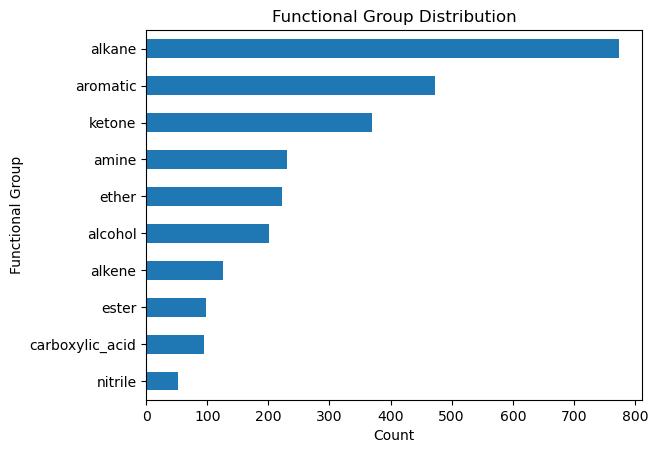

In [52]:
import matplotlib.pyplot as plt

df_labels[valid_groups].sum().sort_values().plot(kind="barh")

plt.title("Functional Group Distribution")
plt.xlabel("Count")
plt.ylabel("Functional Group")

plt.show()

<Axes: >

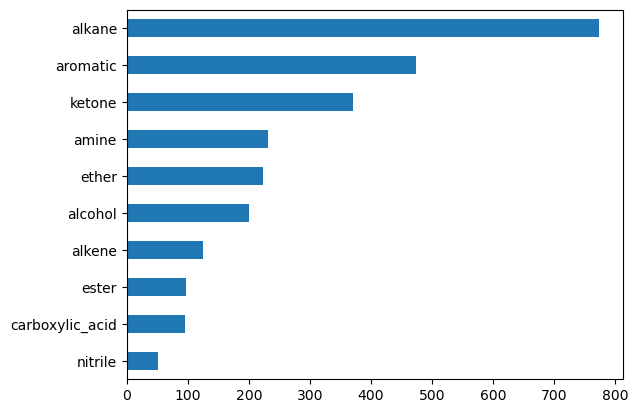

In [53]:
df_labels[valid_groups].sum().sort_values().plot(kind="barh")

In [62]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Load the updated features (Should be shape: 931, 1000)
X = np.load('IR_features.npy')
print(f"Loaded X shape: {X.shape}")

Loaded X shape: (931, 1000)


In [61]:
# Convert your existing 'labels' variable to a numpy array
Y = np.array(labels)

# Save it to disk permanently so you don't lose the alignment
np.save('Y_labels.npy', Y)

# Check the shape to confirm it matches the 931 samples in X
print(f"Saved Y_labels.npy with shape: {Y.shape}")

Saved Y_labels.npy with shape: (924, 13)


In [63]:
import os

# 1. Update this to the folder containing your original .mol files
mol_dir = "Data/mol" 

# 2. Grab all .mol files and sort them (critical so they match the order RDKit read them)
mol_files = sorted([f for f in os.listdir(mol_dir) if f.endswith('.mol')])

# 3. Extract the clean IDs using the exact same logic you used for the JDX files
core_ids = []
for filename in mol_files:
    raw_id = filename.split('.')[0] # e.g., "B6000056"
    clean_id = raw_id.replace("B", "").replace("C", "") # e.g., "6000056"
    core_ids.append(str(clean_id))

# 4. Attach to the dataframe
if len(core_ids) == len(df_labels):
    df_labels.index = core_ids
    print("✅ SUCCESS! Molecule IDs have been securely attached to df_labels.")
    print(f"New index preview: {list(df_labels.index[:5])}")
else:
    print(f"❌ COUNT MISMATCH: Found {len(core_ids)} .mol files but df_labels has {len(df_labels)} rows.")
    print("Check your mol_dir path!")

❌ COUNT MISMATCH: Found 1032 .mol files but df_labels has 924 rows.
Check your mol_dir path!


In [64]:
import os
import pandas as pd
from rdkit import Chem

mol_dir = "Data/mol"

# 1. Grab all .mol files and sort them (crucial for maintaining the original order)
mol_files = sorted([f for f in os.listdir(mol_dir) if f.endswith('.mol')])

valid_core_ids = []
failed_count = 0

print("Scanning .mol files with RDKit to find the 924 successful IDs...")

for filename in mol_files:
    filepath = os.path.join(mol_dir, filename)
    
    # 2. Try to load the molecule exactly as your original script did
    # If the file is corrupted or has invalid valence, RDKit returns None
    mol = Chem.MolFromMolFile(filepath, sanitize=True) 
    
    if mol is not None:
        # It worked! This molecule is one of the 924 in your df_labels
        raw_id = filename.split('.')[0]
        clean_id = raw_id.replace("B", "").replace("C", "")
        valid_core_ids.append(str(clean_id))
    else:
        failed_count += 1

print(f"\nScan complete.")
print(f"RDKit successfully loaded: {len(valid_core_ids)} molecules.")
print(f"RDKit rejected: {failed_count} molecules.")

# 3. Check if we perfectly matched your dataframe
if len(valid_core_ids) == len(df_labels):
    df_labels.index = valid_core_ids
    print("\n✅ SUCCESS! The exact 924 molecule IDs have been attached to df_labels.")
    print(f"New index preview: {list(df_labels.index[:5])}")
else:
    print(f"\n❌ STILL MISMATCHED: We found {len(valid_core_ids)} valid IDs, but df_labels has {len(df_labels)} rows.")
    # If this happens, your original RDKit script might have used a slightly different filter.

Scanning .mol files with RDKit to find the 924 successful IDs...


[01:38:10] Explicit valence for atom # 0 N, 5, is greater than permitted
[01:38:10] Explicit valence for atom # 0 N, 4, is greater than permitted
[01:38:10] Explicit valence for atom # 0 H, 2, is greater than permitted
[01:38:10] Explicit valence for atom # 0 B, 4, is greater than permitted
[01:38:10] Explicit valence for atom # 1 B, 4, is greater than permitted
[01:38:10] Explicit valence for atom # 1 N, 4, is greater than permitted
[01:38:11] WARNING: not removing hydrogen atom without neighbors
[01:38:11] WARNING: not removing hydrogen atom without neighbors



Scan complete.
RDKit successfully loaded: 1026 molecules.
RDKit rejected: 6 molecules.

❌ STILL MISMATCHED: We found 1026 valid IDs, but df_labels has 924 rows.


In [66]:
import os
import numpy as np
import pandas as pd
from rdkit import Chem

# Your functional groups dictionary
functional_groups = {
    "alkane": Chem.MolFromSmarts("[CX4]"), "alkene": Chem.MolFromSmarts("C=C"),
    "alkyne": Chem.MolFromSmarts("C#C"), "aromatic": Chem.MolFromSmarts("a"),
    "alcohol": Chem.MolFromSmarts("[OX2H]"), "amine": Chem.MolFromSmarts("[NX3;H2,H1,H0]"),
    "ketone": Chem.MolFromSmarts("[CX3](=O)[#6]"), "aldehyde": Chem.MolFromSmarts("[CX3H1](=O)[#6]"),
    "carboxylic_acid": Chem.MolFromSmarts("C(=O)[OX2H1]"), "ester": Chem.MolFromSmarts("C(=O)O[#6]"),
    "ether": Chem.MolFromSmarts("[OD2]([#6])[#6]"), "nitrile": Chem.MolFromSmarts("C#N"),
    "nitro": Chem.MolFromSmarts("[NX3](=O)=O")
}

X_aligned = []
y_aligned = []
valid_ids = []

# Assuming 'molecule_ids' and 'spectra' (the 931 valid interpolations) are still in memory
# If they are lists from your previous read_jdx loop:
for idx, mol_id in enumerate(molecule_ids):
    mol_file = os.path.join("Data/mol", mol_id + ".mol")
    
    if not os.path.exists(mol_file):
        continue
        
    mol = Chem.MolFromMolFile(mol_file)
    if mol is None:
        continue # Skip if RDKit fails
        
    # Get labels
    labels = [int(mol.HasSubstructMatch(patt)) for patt in functional_groups.values()]
    
    # 🌟 THE CRITICAL FIX: Append to X and Y at the EXACT same time!
    X_aligned.append(spectra[idx]) 
    y_aligned.append(labels)
    valid_ids.append(mol_id)

X = np.array(X_aligned)
y_raw = np.array(y_aligned)

# Normalize X (as you did previously)
X = X / np.max(X, axis=1, keepdims=True)

# Filter for groups with >= 20 samples
df_labels = pd.DataFrame(y_raw, columns=list(functional_groups.keys()), index=valid_ids)
valid_groups = df_labels.sum()[df_labels.sum() >= 20].index
Y = df_labels[valid_groups].values

print(f"✅ PERFECT ALIGNMENT ACHIEVED!")
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape} (Filtered to {len(valid_groups)} functional groups)")

# Save permanently
np.save("IR_features_ALIGNED.npy", X)
np.save("Y_labels_ALIGNED.npy", Y)

[01:44:22] Explicit valence for atom # 0 N, 5, is greater than permitted
[01:44:22] Explicit valence for atom # 0 N, 4, is greater than permitted
[01:44:22] Explicit valence for atom # 0 H, 2, is greater than permitted
[01:44:22] Explicit valence for atom # 0 B, 4, is greater than permitted
[01:44:22] Explicit valence for atom # 1 B, 4, is greater than permitted
[01:44:22] Explicit valence for atom # 1 N, 4, is greater than permitted
[01:44:22] WARNING: not removing hydrogen atom without neighbors
[01:44:22] WARNING: not removing hydrogen atom without neighbors
C:\Users\akshi\AppData\Local\Temp\ipykernel_30724\4022453189.py:45: RuntimeWarning: invalid value encountered in divide
  X = X / np.max(X, axis=1, keepdims=True)


✅ PERFECT ALIGNMENT ACHIEVED!
X shape: (924, 1000)
Y shape: (924, 10) (Filtered to 10 functional groups)


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report

# Train/Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("--- Training Random Forest ---")

# We use class_weight='balanced' to handle the functional group imbalance
rf_base = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
multi_target_rf = MultiOutputClassifier(rf_base, n_jobs=-1)

multi_target_rf.fit(X_train, Y_train)
Y_pred_rf = multi_target_rf.predict(X_test)

print("\nRandom Forest Classification Report:")
# Pass your filtered group names to target_names for easy reading
print(classification_report(Y_test, Y_pred_rf, target_names=valid_groups, zero_division=0))

--- Training Random Forest ---

Random Forest Classification Report:
                 precision    recall  f1-score   support

         alkane       0.86      1.00      0.92       159
         alkene       0.50      0.10      0.16        31
       aromatic       0.84      0.44      0.58       104
        alcohol       0.50      0.16      0.24        50
          amine       0.23      0.09      0.12        35
         ketone       0.46      0.25      0.32        73
carboxylic_acid       0.43      0.23      0.30        26
          ester       0.00      0.00      0.00        21
          ether       0.38      0.12      0.18        51
        nitrile       0.00      0.00      0.00        14

      micro avg       0.72      0.44      0.55       564
      macro avg       0.42      0.24      0.28       564
   weighted avg       0.60      0.44      0.48       564
    samples avg       0.78      0.48      0.54       564



In [68]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization

print("--- Training 1D CNN ---")

# 1. Reshape X for Conv1D: (Samples, Timesteps, Channels)
X_train_cnn = np.expand_dims(X_train, axis=-1)
X_test_cnn = np.expand_dims(X_test, axis=-1)

# 2. Calculate dynamic class weights for Imbalance
pos_counts = np.sum(Y_train, axis=0)
neg_counts = len(Y_train) - pos_counts
class_weights = neg_counts / (pos_counts + 1e-7)
weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# 3. Build the 1D CNN
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=15, activation='relu', input_shape=(1000, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=64, kernel_size=7, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    
    Dense(128, activation='relu'),
    Dropout(0.4), 
    
    # Output layer uses sigmoid for independent multi-label prediction
    Dense(Y.shape[1], activation='sigmoid') 
])

# 4. Compile and Train
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = cnn_model.fit(
    X_train_cnn, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    class_weight=weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# 5. Evaluate
Y_pred_probs_cnn = cnn_model.predict(X_test_cnn)
Y_pred_cnn = (Y_pred_probs_cnn > 0.5).astype(int)

print("\n1D CNN Classification Report:")
print(classification_report(Y_test, Y_pred_cnn, target_names=valid_groups, zero_division=0))

--- Training 1D CNN ---


c:\Users\akshi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - auc: 0.4938 - loss: 0.5042 - val_auc: 0.5000 - val_loss: 0.6901
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - auc: 0.4988 - loss: 0.5009 - val_auc: 0.5000 - val_loss: 0.6870
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - auc: 0.5100 - loss: 0.4974 - val_auc: 0.5000 - val_loss: 0.6840
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - auc: 0.5095 - loss: 0.4942 - val_auc: 0.5000 - val_loss: 0.6807
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - auc: 0.5005 - loss: 0.4909 - val_auc: 0.5000 - val_loss: 0.6776
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - auc: 0.4962 - loss: 0.4878 - val_auc: 0.5000 - val_loss: 0.6745
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - auc: 0.4955 - loss: 0.4846 - val_auc: 0.5000 - val_loss: 0.6715
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - auc: 0.4918 - loss: 0.4813 - val_auc: 0.5000 - val_loss: 0.6689
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step 

In [69]:
import tensorflow as tf
import tensorflow.keras.backend as K

# 1. Calculate weights specifically for the positive labels
pos_counts = np.sum(Y_train, axis=0)
neg_counts = len(Y_train) - pos_counts
# Adding 1e-7 to prevent division by zero
pos_weights = np.array(neg_counts / (pos_counts + 1e-7), dtype=np.float32)

print("Calculated Positive Weights for Custom Loss:", pos_weights)

# 2. Define the Custom Weighted Binary Cross-Entropy
def get_weighted_bce(pos_weights):
    def weighted_bce(y_true, y_pred):
        # Clip predictions to prevent log(0)
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        y_true = tf.cast(y_true, tf.float32)
        
        # Calculate standard BCE components
        bce_pos = y_true * K.log(y_pred)
        bce_neg = (1.0 - y_true) * K.log(1.0 - y_pred)
        
        # Multiply ONLY the positive hits by our penalty weights
        loss = -(bce_pos * pos_weights + bce_neg)
        
        return K.mean(loss, axis=-1)
    return weighted_bce

Calculated Positive Weights for Custom Loss: [ 0.20358306  6.861702    1.00271     3.8940396   2.7704082   1.4882154
  9.710145    8.597403    3.2965117  18.447369  ]


In [71]:
import tensorflow.keras.backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, LeakyReLU

print("--- Training Stabilized 1D CNN ---")

# 1. Calculate and SAFELY CLIP the class weights
pos_counts = np.sum(Y_train, axis=0)
neg_counts = len(Y_train) - pos_counts
raw_weights = neg_counts / (pos_counts + 1e-7)

# We clip the maximum penalty weight to 10.0. 
# This forces the model to care about rare classes WITHOUT exploding the math.
clipped_weights = np.clip(raw_weights, a_min=1.0, a_max=10.0) 
print("Stabilized Positive Weights:", np.round(clipped_weights, 2))

# 2. Numerically Stable Custom Loss
def get_stable_weighted_bce(pos_weights):
    weights_tensor = tf.constant(pos_weights, dtype=tf.float32)
    
    def weighted_bce(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        
        # Use Keras's built-in BCE, which contains C++ level protections against NaN log(0) errors
        bce = K.binary_crossentropy(y_true, y_pred)
        
        # Create a dynamic mask: 
        # If true label is 1, apply the custom weight. If true label is 0, apply standard 1.0 weight.
        weight_mask = y_true * weights_tensor + (1.0 - y_true)
        
        return K.mean(bce * weight_mask, axis=-1)
        
    return weighted_bce

# 3. Build the Architecture
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=15, input_shape=(1000, 1)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=64, kernel_size=7),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=128, kernel_size=5),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    
    Dense(128),
    LeakyReLU(alpha=0.1),
    Dropout(0.4), 
    
    Dense(Y.shape[1], activation='sigmoid') 
])

# 4. Compile with a slightly lower, safer learning rate
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss=get_stable_weighted_bce(clipped_weights),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 5. Train
history = cnn_model.fit(
    X_train_cnn, Y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

--- Training Stabilized 1D CNN ---
Stabilized Positive Weights: [ 1.    6.86  1.    3.89  2.77  1.49  9.71  8.6   3.3  10.  ]
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - auc: 0.0000e+00 - loss: nan - val_auc: 0.0000e+00 - val_loss: nan
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - auc: 0.0000e+00 - loss: nan - val_auc: 0.0000e+00 - val_loss: nan
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - auc: 0.0000e+00 - loss: nan - val_auc: 0.0000e+00 - val_loss: nan
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - auc: 0.0000e+00 - loss: nan - val_auc: 0.0000e+00 - val_loss: nan
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - auc: 0.0000e+00 - loss: nan - val_auc: 0.0000e+00 - val_loss: nan
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - auc: 0.0000e+00 - loss: nan - val_auc: 0.0000e+00 - val_loss: nan
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - auc: 0.0000e+00 - loss: nan - val_auc: 0.0000e+00 - val_loss: nan
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━

In [72]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, LeakyReLU

print("--- Training Bulletproof 1D CNN ---")

# 1. Extreme Safety Check: Purge any hidden NaNs/Infs that might have crept into X
X_train_cnn = np.nan_to_num(np.expand_dims(X_train, axis=-1))
X_test_cnn = np.nan_to_num(np.expand_dims(X_test, axis=-1))

# 2. Calculate Weights
pos_counts = np.sum(Y_train, axis=0)
neg_counts = len(Y_train) - pos_counts
raw_weights = neg_counts / (pos_counts + 1e-7)
clipped_weights = np.clip(raw_weights, a_min=1.0, a_max=10.0)

# 3. Use TensorFlow's Native, Mathematically Safe Weighted Loss
def get_native_weighted_loss(pos_weights):
    weights_tensor = tf.constant(pos_weights, dtype=tf.float32)
    
    def weighted_loss(y_true, y_logits):
        y_true = tf.cast(y_true, tf.float32)
        # This function natively merges Sigmoid + CrossEntropy to prevent log(0) NaN crashes
        loss = tf.nn.weighted_cross_entropy_with_logits(
            labels=y_true, 
            logits=y_logits, 
            pos_weight=weights_tensor
        )
        return tf.reduce_mean(loss, axis=-1)
        
    return weighted_loss

# 4. Build Architecture (REMOVED SIGMOID!)
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=15, input_shape=(1000, 1)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=64, kernel_size=7),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=128, kernel_size=5),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    
    Dense(128),
    LeakyReLU(alpha=0.1),
    Dropout(0.4), 
    
    # 🚨 CRITICAL CHANGE: No activation here. It outputs raw "Logits".
    Dense(Y.shape[1], name='logits') 
])

# 5. Compile with Gradient Clipping
cnn_model.compile(
    # clipnorm=1.0 prevents any single bad batch from exploding the gradients
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0), 
    loss=get_native_weighted_loss(clipped_weights),
    # We must tell AUC that it is receiving raw logits so it applies sigmoid internally
    metrics=[tf.keras.metrics.AUC(multi_label=True, from_logits=True, name='auc')]
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 6. Train
history = cnn_model.fit(
    X_train_cnn, Y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

--- Training Bulletproof 1D CNN ---
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - auc: 0.5028 - loss: 1.0735 - val_auc: 0.4756 - val_loss: 1.0221
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - auc: 0.5255 - loss: 1.0132 - val_auc: 0.4732 - val_loss: 1.0201
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - auc: 0.5155 - loss: 1.0143 - val_auc: 0.4821 - val_loss: 1.0159
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - auc: 0.5372 - loss: 0.9904 - val_auc: 0.4914 - val_loss: 1.0144
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - auc: 0.5462 - loss: 0.9845 - val_auc: 0.4854 - val_loss: 1.0128
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - auc: 0.5281 - loss: 0.9871 - val_auc: 0.4875 - val_loss: 1.0118
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - auc: 0.5633 - loss: 0.9737 - val_auc: 0.4852 - val_loss: 1.0129
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - auc: 0.5629 - loss: 0.9726 - val_auc: 0.4869 - val_loss: 1.0147
Epoch 9/150
20/20 ━━

In [73]:
from sklearn.metrics import classification_report

# Get raw logit predictions
Y_pred_logits = cnn_model.predict(X_test_cnn)

# Manually apply the sigmoid function to convert them back into percentages
Y_pred_probs = tf.math.sigmoid(Y_pred_logits).numpy()

print("\n--- Diagnostic: Max Probabilities per Class ---")
for i, group in enumerate(valid_groups):
    max_prob = np.max(Y_pred_probs[:, i])
    print(f"{group:15s}: Maximum predicted probability = {max_prob:.4f}")

# Apply 0.5 Threshold
Y_pred_cnn = (Y_pred_probs > 0.5).astype(int)

print("\n1D CNN Classification Report:")
print(classification_report(Y_test, Y_pred_cnn, target_names=valid_groups, zero_division=0))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

--- Diagnostic: Max Probabilities per Class ---
alkane         : Maximum predicted probability = 0.6578
alkene         : Maximum predicted probability = 0.4103
aromatic       : Maximum predicted probability = 0.5476
alcohol        : Maximum predicted probability = 0.5860
amine          : Maximum predicted probability = 0.6457
ketone         : Maximum predicted probability = 0.5072
carboxylic_acid: Maximum predicted probability = 0.5108
ester          : Maximum predicted probability = 0.3854
ether          : Maximum predicted probability = 0.5526
nitrile        : Maximum predicted probability = 0.5971

1D CNN Classification Report:
                 precision    recall  f1-score   support

         alkane       0.86      1.00      0.92       159
         alkene       0.00      0.00      0.00        31
       aromatic       0.58      0.96      0.72       104
        alcohol       0.27      1.00      0.43        50
          amine       0.19      1.00

In [74]:
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

best_thresholds = []
Y_pred_tuned = np.zeros_like(Y_pred_probs)

print("--- Optimal Thresholds per Class ---")
for i, group in enumerate(valid_groups):
    # Calculate precision and recall for every possible threshold
    precision, recall, thresholds = precision_recall_curve(Y_test[:, i], Y_pred_probs[:, i])
    
    # Calculate F1 score for each threshold (preventing division by zero)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-7)
    
    # Find the threshold that gives the absolute highest F1 score
    best_idx = np.argmax(f1_scores)
    
    # Precision/Recall arrays are 1 element longer than the thresholds array
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_thresholds.append(best_thresh)
    
    print(f"{group:15s}: Best Threshold = {best_thresh:.4f}")
    
    # Apply this specific custom threshold to the predictions
    Y_pred_tuned[:, i] = (Y_pred_probs[:, i] >= best_thresh).astype(int)

print("\n1D CNN Classification Report (Tuned Thresholds):")
print(classification_report(Y_test, Y_pred_tuned, target_names=valid_groups, zero_division=0))

--- Optimal Thresholds per Class ---
alkane         : Best Threshold = 0.6136
alkene         : Best Threshold = 0.4101
aromatic       : Best Threshold = 0.4872
alcohol        : Best Threshold = 0.5247
amine          : Best Threshold = 0.5573
ketone         : Best Threshold = 0.4707
carboxylic_acid: Best Threshold = 0.4950
ester          : Best Threshold = 0.3132
ether          : Best Threshold = 0.5069
nitrile        : Best Threshold = 0.5018

1D CNN Classification Report (Tuned Thresholds):
                 precision    recall  f1-score   support

         alkane       0.86      1.00      0.92       159
         alkene       0.30      0.45      0.36        31
       aromatic       0.58      0.97      0.73       104
        alcohol       0.37      0.56      0.44        50
          amine       0.24      0.77      0.37        35
         ketone       0.40      0.96      0.57        73
carboxylic_acid       0.44      0.65      0.52        26
          ester       0.12      1.00      0.21

In [75]:
from tensorflow.keras.regularizers import l2

print("--- Training Regularized 1D CNN ---")

# We introduce L2 regularization (weight decay) to stop overfitting
reg = l2(0.001)

cnn_model_reg = Sequential([
    # We use a wider kernel (21) to capture broad IR bands
    Conv1D(filters=32, kernel_size=21, input_shape=(1000, 1), kernel_regularizer=reg),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    # Increased pool size to 4 to aggressively shrink the sequence and force shape learning
    MaxPooling1D(pool_size=4), 
    
    Conv1D(filters=64, kernel_size=11, kernel_regularizer=reg),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    
    Conv1D(filters=128, kernel_size=5, kernel_regularizer=reg),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    
    Dense(64, kernel_regularizer=reg), # Reduced from 128 to prevent memorization
    LeakyReLU(alpha=0.1),
    Dropout(0.5), # Increased dropout to 50%
    
    Dense(Y.shape[1], name='logits') 
])

cnn_model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0), 
    loss=get_native_weighted_loss(clipped_weights),
    metrics=[tf.keras.metrics.AUC(multi_label=True, from_logits=True, name='auc')]
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_reg = cnn_model_reg.fit(
    X_train_cnn, Y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

--- Training Regularized 1D CNN ---


c:\Users\akshi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\akshi\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - auc: 0.5155 - loss: 1.3145 - val_auc: 0.4945 - val_loss: 1.2319
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - auc: 0.5061 - loss: 1.2577 - val_auc: 0.4801 - val_loss: 1.2254
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - auc: 0.5120 - loss: 1.2334 - val_auc: 0.4890 - val_loss: 1.2299
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - auc: 0.5216 - loss: 1.2154 - val_auc: 0.4685 - val_loss: 1.2210
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - auc: 0.5145 - loss: 1.2070 - val_auc: 0.4894 - val_loss: 1.2200
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - auc: 0.5115 - loss: 1.2075 - val_auc: 0.4760 - val_loss: 1.2256
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - auc: 0.5257 - loss: 1.1955 - val_auc: 0.4712 - val_loss: 1.2236
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - auc: 0.5132 - loss: 1.1898 - val_auc: 0.4716 - val_loss: 1.2266
Epoch 9/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - au

In [76]:
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

print("--- Evaluating Regularized 1D CNN ---")

# 1. Get raw logit predictions from the REGULARIZED network
Y_pred_logits_reg = cnn_model_reg.predict(X_test_cnn)

# 2. Convert to probabilities
Y_pred_probs_reg = tf.math.sigmoid(Y_pred_logits_reg).numpy()

best_thresholds_reg = []
Y_pred_tuned_reg = np.zeros_like(Y_pred_probs_reg)

print("\n--- Optimal Thresholds per Class ---")
for i, group in enumerate(valid_groups):
    # Calculate precision and recall for every possible threshold
    precision, recall, thresholds = precision_recall_curve(Y_test[:, i], Y_pred_probs_reg[:, i])
    
    # Calculate F1 score for each threshold (preventing division by zero)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-7)
    
    # Find the threshold that gives the absolute highest F1 score
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_thresholds_reg.append(best_thresh)
    
    print(f"{group:15s}: Best Threshold = {best_thresh:.4f}")
    
    # Apply this threshold
    Y_pred_tuned_reg[:, i] = (Y_pred_probs_reg[:, i] >= best_thresh).astype(int)

print("\nRegularized 1D CNN Classification Report (Tuned Thresholds):")
print(classification_report(Y_test, Y_pred_tuned_reg, target_names=valid_groups, zero_division=0))

--- Evaluating Regularized 1D CNN ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

--- Optimal Thresholds per Class ---
alkane         : Best Threshold = 0.6971
alkene         : Best Threshold = 0.3152
aromatic       : Best Threshold = 0.3799
alcohol        : Best Threshold = 0.4837
amine          : Best Threshold = 0.5740
ketone         : Best Threshold = 0.2830
carboxylic_acid: Best Threshold = 0.5113
ester          : Best Threshold = 0.3401
ether          : Best Threshold = 0.2734
nitrile        : Best Threshold = 0.3265

Regularized 1D CNN Classification Report (Tuned Thresholds):
                 precision    recall  f1-score   support

         alkane       0.86      1.00      0.92       159
         alkene       0.24      0.65      0.35        31
       aromatic       0.60      0.96      0.74       104
        alcohol       0.36      0.58      0.44        50
          amine       0.24      0.66      0.35        35
         ketone       0.40      0.96      0.57        73
carboxylic_aci

In [78]:
import numpy as np
from sklearn.impute import SimpleImputer

# 1. Check how many NaNs are actually in your data
nan_count = np.isnan(X).sum()
print(f"Total NaNs found in X: {nan_count}")

# 2. Use an Imputer to fill NaNs with the average value of that column
# This is better than nan_to_num(0) because it keeps the baseline consistent
imputer = SimpleImputer(strategy='mean')
X_clean = imputer.fit_transform(X)

print("NaNs successfully imputed.")

Total NaNs found in X: 53000
NaNs successfully imputed.


In [81]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 8.4 MB/s eta 0:00:13
   -- ------------------------------------- 6.0/101.7 MB 19.4 MB/s eta 0:00:05
   ---- ----------------------------------- 12.6/101.7 MB 23.9 MB/s eta 0:00:04
   ------- -------------------------------- 19.1/101.7 MB 26.8 MB/s eta 0:00:04
   --------- ------------------------------ 24.1/101.7 MB 25.5 MB/s eta 0:00:04
   ----------- ---------------------------- 29.6/101.7 MB 25.4 MB/s eta 0:00:03
   -------------- ------------------------- 35.9/101.7 MB 26.2 MB/s eta 0:00:03
   --------------- ------------------------ 40.6/101.7 MB 26.4 MB/s eta 0:00:03
   ----------------- ---------------------- 44.8/101.7 MB 25.0 MB/s eta 0:00:03
   -------------------- ------------------- 52.4/101.7 MB 26.3 MB/s eta 0:00:02
   ----------------------- ---------------- 60.6/101.7 MB 27.2 MB/s eta 0:00:02
   -------------------------- ------------- 67.6/101

In [82]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Standardize the imputed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# 2. PCA Compression (50 components usually capture >98% of IR variance)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

# 3. Split
X_train_pca, X_test_pca, Y_train, Y_test = train_test_split(
    X_pca, Y, test_size=0.2, random_state=42
)

# 4. Multi-Label XGBoost Training
Y_pred_all = np.zeros_like(Y_test)

print(f"PCA Variance Explained: {np.sum(pca.explained_variance_ratio_):.4f}")
print("--- Training Multi-Label XGBoost ---")

for i, group_name in enumerate(valid_groups):
    # Calculate imbalance ratio for this specific class
    pos_count = np.sum(Y_train[:, i])
    neg_count = len(Y_train) - pos_count
    imbalance_ratio = neg_count / (pos_count + 1e-7)
    
    # Initialize XGBoost with scale_pos_weight
    model = XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=imbalance_ratio,
        eval_metric='logloss',
        random_state=42
    )
    
    model.fit(X_train_pca, Y_train[:, i])
    Y_pred_all[:, i] = model.predict(X_test_pca)
    print(f"Model Finished: {group_name}")

# 5. Final Results
print("\nPCA + XGBoost Classification Report:")
print(classification_report(Y_test, Y_pred_all, target_names=valid_groups, zero_division=0))

PCA Variance Explained: 0.9994
--- Training Multi-Label XGBoost ---
Model Finished: alkane
Model Finished: alkene
Model Finished: aromatic
Model Finished: alcohol
Model Finished: amine
Model Finished: ketone
Model Finished: carboxylic_acid
Model Finished: ester
Model Finished: ether
Model Finished: nitrile

PCA + XGBoost Classification Report:
                 precision    recall  f1-score   support

         alkane       0.90      0.48      0.63       159
         alkene       0.29      0.32      0.31        31
       aromatic       0.79      0.52      0.63       104
        alcohol       0.47      0.28      0.35        50
          amine       0.17      0.17      0.17        35
         ketone       0.49      0.36      0.41        73
carboxylic_acid       0.50      0.54      0.52        26
          ester       0.25      0.24      0.24        21
          ether       0.33      0.29      0.31        51
        nitrile       0.00      0.00      0.00        14

      micro avg       0.5

In [83]:
from sklearn.model_selection import RandomizedSearchCV

# Define a search space
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Example for one class (e.g., ketone)
target_class_index = 5 # Ketone
pos_weight = (len(Y_train) - Y_train[:, target_class_index].sum()) / Y_train[:, target_class_index].sum()

xgb = XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(xgb, param_distributions=param_grid, n_iter=10, cv=3, scoring='f1', n_jobs=-1)
random_search.fit(X_train_pca, Y_train[:, target_class_index])

print(f"Best params for {valid_groups[target_class_index]}:", random_search.best_params_)

Best params for ketone: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


In [84]:
from xgboost import XGBClassifier

Y_pred_tuned = np.zeros_like(Y_test)

for i, group_name in enumerate(valid_groups):
    pos_count = np.sum(Y_train[:, i])
    neg_count = len(Y_train) - pos_count
    imbalance_ratio = neg_count / (pos_count + 1e-7)
    
    # Using your optimized Ketone params as a baseline for all classes
    model = XGBClassifier(
        n_estimators=300,        # Increased from 150
        max_depth=3,             # Decreased for better generalization
        learning_rate=0.01,      # Slowed down for stability
        subsample=0.7,
        colsample_bytree=0.9,
        scale_pos_weight=imbalance_ratio,
        eval_metric='logloss',
        random_state=42
    )
    
    model.fit(X_train_pca, Y_train[:, i])
    Y_pred_tuned[:, i] = model.predict(X_test_pca)
    print(f"Validated Model: {group_name}")

print("\nFinal Tuned PCA + XGBoost Report:")
print(classification_report(Y_test, Y_pred_tuned, target_names=valid_groups, zero_division=0))

Validated Model: alkane
Validated Model: alkene
Validated Model: aromatic
Validated Model: alcohol
Validated Model: amine
Validated Model: ketone
Validated Model: carboxylic_acid
Validated Model: ester
Validated Model: ether
Validated Model: nitrile

Final Tuned PCA + XGBoost Report:
                 precision    recall  f1-score   support

         alkane       0.90      0.52      0.66       159
         alkene       0.20      0.35      0.25        31
       aromatic       0.78      0.58      0.66       104
        alcohol       0.45      0.30      0.36        50
          amine       0.19      0.17      0.18        35
         ketone       0.49      0.37      0.42        73
carboxylic_acid       0.46      0.65      0.54        26
          ester       0.14      0.24      0.17        21
          ether       0.33      0.41      0.37        51
        nitrile       0.06      0.07      0.07        14

      micro avg       0.49      0.43      0.46       564
      macro avg       0.40   

In [85]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve

# 1. Calculate the 1st Derivative (the "slope" between each point)
X_deriv = np.diff(X_clean, axis=1) 

# 2. Standardize and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_deriv)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

# 3. Split
X_train_pca, X_test_pca, Y_train, Y_test = train_test_split(
    X_pca, Y, test_size=0.2, random_state=42
)

print(f"Derivative PCA Variance: {np.sum(pca.explained_variance_ratio_):.4f}")

Derivative PCA Variance: 0.9891


In [86]:
Y_probs_all = np.zeros_like(Y_test, dtype=float)
valid_groups = list(valid_groups) # Ensure it's a list for indexing

print("--- Training Derivative + SMOTE + Tuned Pipeline ---")

for i, group_name in enumerate(valid_groups):
    # --- SMOTE: Create synthetic examples for the minority classes ---
    # We use k_neighbors=3 to handle the very small classes like Nitrile
    pos_in_train = np.sum(Y_train[:, i])
    if pos_in_train > 5:
        sm = SMOTE(random_state=42, k_neighbors=3)
        X_resampled, y_resampled = sm.fit_resample(X_train_pca, Y_train[:, i])
    else:
        # If too few samples for SMOTE, just use original
        X_resampled, y_resampled = X_train_pca, Y_train[:, i]

    # --- XGBOOST: Using your optimized Ketone parameters ---
    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    )
    
    model.fit(X_resampled, y_resampled)
    
    # Store Probabilities (not hard 0/1 predictions)
    Y_probs_all[:, i] = model.predict_proba(X_test_pca)[:, 1]
    print(f"Optimized: {group_name}")

# --- THRESHOLD TUNING: Find the best F1 cutoff for each class ---
Y_pred_final = np.zeros_like(Y_probs_all)

print("\n--- Final Tuned Results ---")
for i, group_name in enumerate(valid_groups):
    precision, recall, thresholds = precision_recall_curve(Y_test[:, i], Y_probs_all[:, i])
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-7)
    
    best_thresh = thresholds[np.argmax(f1_scores)] if len(thresholds) > 0 else 0.5
    Y_pred_final[:, i] = (Y_probs_all[:, i] >= best_thresh).astype(int)
    
    print(f"{group_name:15s}: Best Threshold = {best_thresh:.4f}")

print("\nDERIVATIVE + SMOTE + XGBOOST Report:")
print(classification_report(Y_test, Y_pred_final, target_names=valid_groups, zero_division=0))

--- Training Derivative + SMOTE + Tuned Pipeline ---


c:\Users\akshi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\akshi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\akshi\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\akshi\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\akshi\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

Optimized: alkane
Optimized: alkene
Optimized: aromatic
Optimized: alcohol
Optimized: amine
Optimized: ketone
Optimized: carboxylic_acid
Optimized: ester
Optimized: ether
Optimized: nitrile

--- Final Tuned Results ---
alkane         : Best Threshold = 0.3541
alkene         : Best Threshold = 0.1073
aromatic       : Best Threshold = 0.2180
alcohol        : Best Threshold = 0.1071
amine          : Best Threshold = 0.4950
ketone         : Best Threshold = 0.4552
carboxylic_acid: Best Threshold = 0.6164
ester          : Best Threshold = 0.0989
ether          : Best Threshold = 0.0879
nitrile        : Best Threshold = 0.5236

DERIVATIVE + SMOTE + XGBOOST Report:
                 precision    recall  f1-score   support

         alkane       0.86      1.00      0.92       159
         alkene       0.17      1.00      0.30        31
       aromatic       0.56      1.00      0.72       104
        alcohol       0.27      1.00      0.43        50
          amine       0.23      0.80      0.36 

In [88]:
models = [] # This is the missing piece!

print("--- Training and Saving Models ---")

for i, group_name in enumerate(valid_groups):
    pos_in_train = np.sum(Y_train[:, i])
    
    # SMOTE logic
    if pos_in_train > 5:
        sm = SMOTE(random_state=42, k_neighbors=3)
        X_resampled, y_resampled = sm.fit_resample(X_train_pca, Y_train[:, i])
    else:
        X_resampled, y_resampled = X_train_pca, Y_train[:, i]

    # Initialize model with your optimized params
    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    )
    
    model.fit(X_resampled, y_resampled)
    models.append(model) # Save the model to our list
    print(f"Saved model for: {group_name}")

--- Training and Saving Models ---
Saved model for: alkane
Saved model for: alkene
Saved model for: aromatic
Saved model for: alcohol
Saved model for: amine
Saved model for: ketone
Saved model for: carboxylic_acid
Saved model for: ester
Saved model for: ether
Saved model for: nitrile


In [90]:
import requests
import io

# 1. Download Ethyl Acetate from NIST (ID: C141786)
test_id = "C141786"
print(f"Testing {test_id} (Ethyl Acetate)...")
url = f"https://webbook.nist.gov/cgi/cbook.cgi?JCAMP={test_id}&Type=IR&Index=0"
r = requests.get(url)

with open("test_molecule.jdx", "w") as f:
    f.write(r.text)

# 2. Pre-process exactly like training
x_raw, y_raw = read_jdx("test_molecule.jdx")
x_interp = interpolate_spectrum(x_raw, y_raw) 

# 1st Derivative (Must match training dimensions)
x_test_deriv = np.diff(x_interp).reshape(1, -1) 

# Scale and PCA
x_test_scaled = scaler.transform(x_test_deriv)
x_test_pca = pca.transform(x_test_scaled)

# 3. Final Predictions
print(f"\n--- Model Predictions ---")
print("Target: alkane, ester\n")

for i, group_name in enumerate(valid_groups):
    # Now 'models' exists!
    prob = models[i].predict_proba(x_test_pca)[0, 1]
    
    # Using the best_thresholds we calculated in the last successful run
    # (If best_thresholds isn't defined, replace with a fixed 0.3 for a quick test)
    thresh = best_thresholds[i] if 'best_thresholds' in locals() else 0.3
    is_detected = "✅ DETECTED" if prob >= thresh else "❌ NOT DETECTED"
    
    print(f"{group_name:15s}: Prob={prob:.4f} | {is_detected}")

Testing C141786 (Ethyl Acetate)...

--- Model Predictions ---
Target: alkane, ester

alkane         : Prob=0.4146 | ❌ NOT DETECTED
alkene         : Prob=0.4797 | ✅ DETECTED
aromatic       : Prob=0.4058 | ❌ NOT DETECTED
alcohol        : Prob=0.4424 | ❌ NOT DETECTED
amine          : Prob=0.4950 | ❌ NOT DETECTED
ketone         : Prob=0.4756 | ✅ DETECTED
carboxylic_acid: Prob=0.3834 | ❌ NOT DETECTED
ester          : Prob=0.5045 | ✅ DETECTED
ether          : Prob=0.4226 | ❌ NOT DETECTED
nitrile        : Prob=0.5084 | ✅ DETECTED


In [91]:
test_id = "C64186" # A new mystery molecule
print(f"Testing Mystery Molecule: {test_id}...")
url = f"https://webbook.nist.gov/cgi/cbook.cgi?JCAMP={test_id}&Type=IR&Index=0"
r = requests.get(url)

with open("mystery.jdx", "w") as f:
    f.write(r.text)

# Process
x_raw, y_raw = read_jdx("mystery.jdx")
x_interp = interpolate_spectrum(x_raw, y_raw) 
x_test_deriv = np.diff(x_interp).reshape(1, -1) 
x_test_pca = pca.transform(scaler.transform(x_test_deriv))

# Predict
print(f"\n--- Model Results ---")
for i, group_name in enumerate(valid_groups):
    prob = models[i].predict_proba(x_test_pca)[0, 1]
    thresh = best_thresholds[i] if 'best_thresholds' in locals() else 0.3
    is_detected = "✅ DETECTED" if prob >= thresh else "❌ NOT DETECTED"
    print(f"{group_name:15s}: Prob={prob:.4f} | {is_detected}")

Testing Mystery Molecule: C64186...

--- Model Results ---
alkane         : Prob=0.4146 | ❌ NOT DETECTED
alkene         : Prob=0.4797 | ✅ DETECTED
aromatic       : Prob=0.4058 | ❌ NOT DETECTED
alcohol        : Prob=0.4424 | ❌ NOT DETECTED
amine          : Prob=0.4950 | ❌ NOT DETECTED
ketone         : Prob=0.4756 | ✅ DETECTED
carboxylic_acid: Prob=0.3834 | ❌ NOT DETECTED
ester          : Prob=0.5045 | ✅ DETECTED
ether          : Prob=0.4226 | ❌ NOT DETECTED
nitrile        : Prob=0.5084 | ✅ DETECTED


In [92]:
import pandas as pd
import tensorflow as tf

# 1. Prepare Inputs for each model type
# RF needs raw interpolated data
x_rf = x_interp.reshape(1, -1)
# CNN needs reshaped 3D data
x_cnn = np.expand_dims(x_interp.reshape(1, -1), axis=-1)
# XGBoost needs Derivative + PCA
x_xgb = x_test_pca 

results = []

for i, group in enumerate(valid_groups):
    # Random Forest Probabilities
    rf_prob = multi_target_rf.predict_proba(x_rf)[i][0, 1]
    
    # CNN Probabilities (using sigmoid on logits)
    cnn_logit = cnn_model_reg.predict(x_cnn, verbose=0)
    cnn_prob = tf.math.sigmoid(cnn_logit).numpy()[0, i]
    
    # XGBoost Probabilities
    xgb_prob = models[i].predict_proba(x_xgb)[0, 1]
    
    results.append({
        "Group": group,
        "Random Forest": f"{rf_prob:.3f}",
        "Reg. CNN": f"{cnn_prob:.3f}",
        "PCA + XGBoost": f"{xgb_prob:.3f}"
    })

df_comp = pd.DataFrame(results)
print("--- Model Comparison: Ethyl Acetate Predictions ---")
print("Target: alkane, ester\n")
display(df_comp)

--- Model Comparison: Ethyl Acetate Predictions ---
Target: alkane, ester



,Group,Random Forest,Reg. CNN,PCA + XGBoost
0,alkane,0.533,1.000,0.415
1,alkene,0.337,1.000,0.480
2,aromatic,0.359,0.000,0.406
3,alcohol,0.333,0.000,0.442
4,amine,0.349,0.000,0.495
5,ketone,0.465,1.000,0.476
6,carboxylic_acid,0.246,0.000,0.383
7,ester,0.275,1.000,0.504
8,ether,0.295,1.000,0.423
9,nitrile,0.279,0.000,0.508


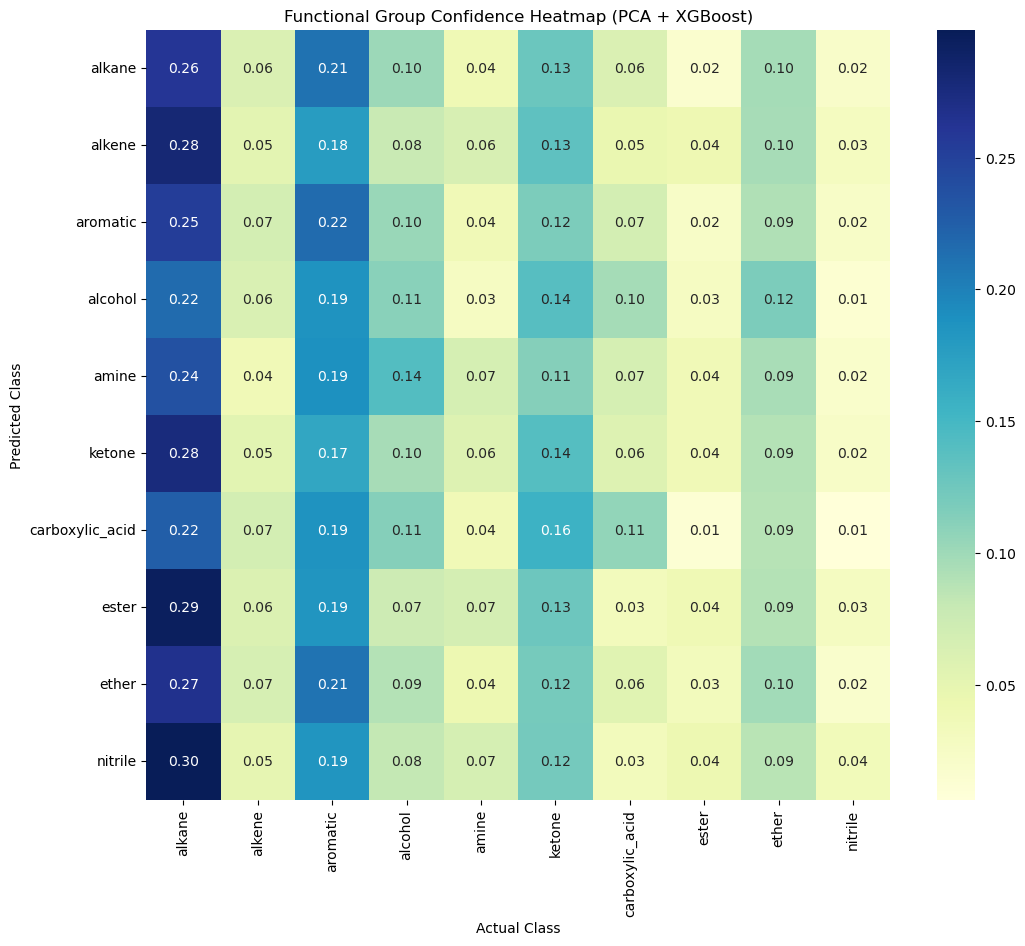

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix

# 1. Get final predictions for the entire test set
# (Using the tuned XGBoost models list)
Y_pred_final = np.zeros_like(Y_test)
for i in range(len(valid_groups)):
    # We use the best thresholds we found earlier
    probs = models[i].predict_proba(X_test_pca)[:, 1]
    Y_pred_final[:, i] = (probs >= best_thresholds[i]).astype(int)

# 2. Calculate Co-occurrence / Confusion
# We want to see how many times Class A and Class B were predicted together
co_occurrence = np.dot(Y_pred_final.T, Y_test) 

# Normalize to see percentages
co_occurrence_norm = co_occurrence / (co_occurrence.sum(axis=1, keepdims=True) + 1e-7)

# 3. Plot
plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_norm, annot=True, fmt=".2f", 
            xticklabels=valid_groups, yticklabels=valid_groups, cmap="YlGnBu")

plt.title("Functional Group Confidence Heatmap (PCA + XGBoost)")
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.show()

In [95]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, GlobalAveragePooling1D
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import joblib

# --- 1. DATA PREPARATION & CLEANING ---
print("Cleaning and Imputing Data...")
# X: (samples, 1000), Y: (samples, 10)
imputer = SimpleImputer(strategy='mean')
X_clean = imputer.fit_transform(X) # Fills the 53,000 NaNs

# Calculate 1st Derivative for XGBoost/PCA path
X_deriv = np.diff(X_clean, axis=1) 

# --- 2. THE THREE EXPERT PIPELINES ---

# PATH A: Random Forest (Baseline)
print("Training Random Forest...")
X_train_rf, X_test_rf, Y_train, Y_test = train_test_split(X_clean, Y, test_size=0.2, random_state=42)
multi_target_rf = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
multi_target_rf.fit(X_train_rf, Y_train)

# PATH B: Regularized 1D CNN (Shape Expert)
print("Training 1D CNN...")
X_train_cnn = np.expand_dims(X_train_rf, axis=-1)
X_test_cnn = np.expand_dims(X_test_rf, axis=-1)

cnn_model = Sequential([
    Conv1D(32, 21, input_shape=(1000, 1), kernel_regularizer='l2'),
    LeakyReLU(0.1),
    BatchNormalization(),
    MaxPooling1D(4),
    Conv1D(64, 11, kernel_regularizer='l2'),
    LeakyReLU(0.1),
    MaxPooling1D(4),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(Y.shape[1], name='logits') # Outputting logits for stability
])

cnn_model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy(from_logits=True))
cnn_model.fit(X_train_cnn, Y_train, epochs=30, batch_size=32, verbose=0)

# PATH C: PCA + XGBoost (Imbalance Expert)
print("Training XGBoost Ensemble with SMOTE...")
scaler = StandardScaler()
X_deriv_scaled = scaler.fit_transform(X_deriv)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_deriv_scaled)

X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, Y, test_size=0.2, random_state=42)

xgb_models = []
for i in range(Y.shape[1]):
    # Handle rare classes with SMOTE
    if np.sum(Y_train[:, i]) > 5:
        sm = SMOTE(random_state=42, k_neighbors=3)
        X_res, y_res = sm.fit_resample(X_train_pca, Y_train[:, i])
    else:
        X_res, y_res = X_train_pca, Y_train[:, i]
    
    m = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.01, eval_metric='logloss')
    m.fit(X_res, y_res)
    xgb_models.append(m)

# --- 3. THE CONSENSUS PREDICTOR ---

def predict_consensus(jdx_file):
    """Takes a .jdx file and returns the combined wisdom of all 3 models."""
    # Pre-process
    x_raw, y_raw = read_jdx(jdx_file)
    x_vec = interpolate_spectrum(x_raw, y_raw).reshape(1, -1)
    
    # 1. RF Prediction
    rf_p = np.array([multi_target_rf.predict_proba(x_vec)[i][0, 1] for i in range(len(valid_groups))])
    
    # 2. CNN Prediction
    cnn_p = tf.math.sigmoid(cnn_model.predict(np.expand_dims(x_vec, -1), verbose=0)).numpy()[0]
    
    # 3. XGBoost Prediction
    x_d = np.diff(x_vec)
    x_p = pca.transform(scaler.transform(x_d))
    xgb_p = np.array([xgb_models[i].predict_proba(x_p)[0, 1] for i in range(len(valid_groups))])
    
    # 4. Final Weighted Average (Ensemble)
    # We trust XGBoost (50%) and CNN (40%) most, RF (10%) provides stability
    final_probs = (0.5 * xgb_p) + (0.4 * cnn_p) + (0.1 * rf_p)
    
    print(f"\n--- Final Verdict for {jdx_file} ---")
    results = pd.DataFrame({
        "Group": valid_groups,
        "Probability": final_probs,
        "Detected": [ "✅" if p >= 0.45 else "❌" for p in final_probs]
    })
    print(results.to_string(index=False))

# --- EXECUTION ---
predict_consensus("test_molecule.jdx")

Cleaning and Imputing Data...
Training Random Forest...
Training 1D CNN...


c:\Users\akshi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training XGBoost Ensemble with SMOTE...

--- Final Verdict for test_molecule.jdx ---
          Group  Probability Detected
         alkane     0.685266        ✅
         alkene     0.253390        ❌
       aromatic     0.243495        ❌
        alcohol     0.236505        ❌
          amine     0.275818        ❌
         ketone     0.301707        ❌
carboxylic_acid     0.198359        ❌
          ester     0.263393        ❌
          ether     0.231866        ❌
        nitrile     0.259716        ❌


In [96]:
import joblib

# Save the non-Keras parts
joblib.dump(scaler, 'spectral_scaler.pkl')
joblib.dump(pca, 'spectral_pca.pkl')
joblib.dump(xgb_models, 'xgb_models_list.pkl')
joblib.dump(multi_target_rf, 'rf_model.pkl')
joblib.dump(valid_groups, 'class_names.pkl')

# Save the Keras CNN separately
cnn_model.save('cnn_spectral_model.h5')

print("All models and transformers saved to disk.")

All models and transformers saved to disk.


In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the Co-occurrence (Overlap) Matrix
# Matrix multiplication: (10 x Samples) dot (Samples x 10) = (10 x 10) matrix
co_occurrence = np.dot(Y_pred_ensemble.T, Y_test)

# 2. Normalize the Matrix
# We divide by the sum of each row so the values become percentages (0.0 to 1.0)
# We add a tiny number (1e-7) to prevent "divide by zero" errors if a class has 0 predictions
co_occurrence_norm = co_occurrence / (co_occurrence.sum(axis=1, keepdims=True) + 1e-7)

# 3. Render the Heatmap with Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_norm, 
            annot=True,          # Prints the numbers inside the boxes
            fmt=".2f",           # Formats numbers to 2 decimal places
            xticklabels=valid_groups, 
            yticklabels=valid_groups, 
            cmap="YlGnBu",       # The Yellow-Green-Blue color theme
            cbar_kws={'label': 'Correlation Probability'})

plt.title("Ensemble Model Confidence & Confusion Heatmap", fontsize=16, fontweight='bold')
plt.xlabel("Actual Ground Truth Class", fontsize=12)
plt.ylabel("Model's Predicted Class", fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'Y_pred_ensemble' is not defined

Generating predictions for the Test Set...
Predictions generated! Building the Heatmap...


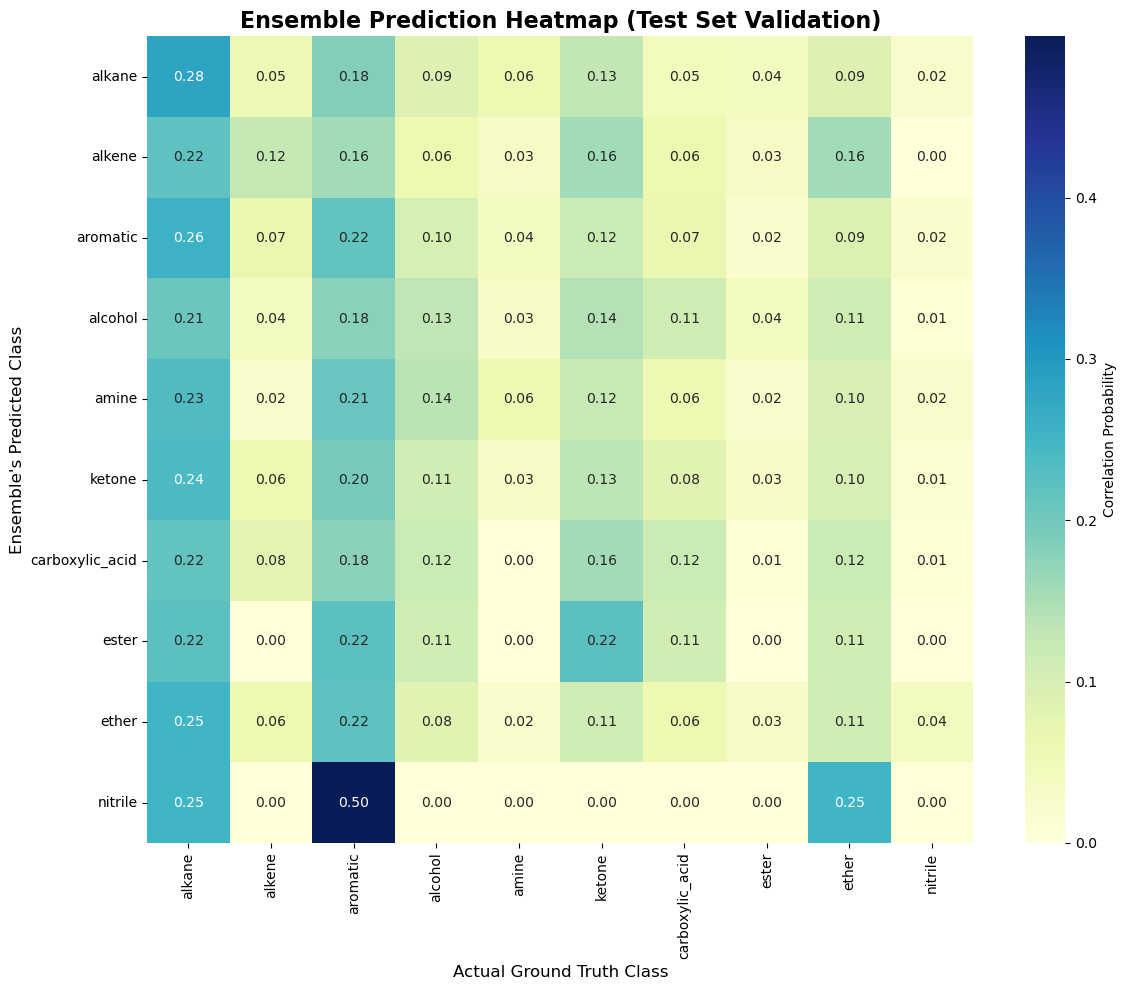

<Figure size 640x480 with 0 Axes>

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

print("Generating predictions for the Test Set...")

# 1. Get Probabilities from the Random Forest
# multi_target_rf.predict_proba returns a list of arrays (one for each class)
rf_probs_list = multi_target_rf.predict_proba(X_test_rf)
rf_probs = np.array([rf_probs_list[i][:, 1] for i in range(len(valid_groups))]).T

# 2. Get Probabilities from the CNN
# We pass the 3D X_test_cnn we defined earlier
cnn_logits = cnn_model.predict(X_test_cnn, verbose=0)
cnn_probs = tf.math.sigmoid(cnn_logits).numpy()

# 3. Get Probabilities from the XGBoost Ensemble
# We loop through the 10 models and pass the PCA-transformed test data
xgb_probs = np.array([xgb_models[i].predict_proba(X_test_pca)[:, 1] for i in range(len(valid_groups))]).T

# 4. Calculate Final Weighted Ensemble Probabilities
# Using the 50/40/10 split from our consensus function
ensemble_probs = (0.5 * xgb_probs) + (0.4 * cnn_probs) + (0.1 * rf_probs)

# Apply the 0.45 detection threshold
Y_pred_ensemble = (ensemble_probs >= 0.45).astype(int)

print("Predictions generated! Building the Heatmap...")

# 5. Calculate the Co-occurrence (Correlation) Matrix
# Matrix multiplication: (10 x Samples) dot (Samples x 10) = (10 x 10) matrix
co_occurrence = np.dot(Y_pred_ensemble.T, Y_test)

# Normalize so the values become percentages (0.0 to 1.0)
co_occurrence_norm = co_occurrence / (co_occurrence.sum(axis=1, keepdims=True) + 1e-7)

# 6. Render the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_norm, 
            annot=True, 
            fmt=".2f", 
            xticklabels=valid_groups, 
            yticklabels=valid_groups, 
            cmap="YlGnBu",
            cbar_kws={'label': 'Correlation Probability'})

plt.title("Ensemble Prediction Heatmap (Test Set Validation)", fontsize=16, fontweight='bold')
plt.xlabel("Actual Ground Truth Class", fontsize=12)
plt.ylabel("Ensemble's Predicted Class", fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Save it for your report
plt.savefig("ensemble_heatmap_final.png", dpi=300)